# 01 EDA Startup Diagnostics

This notebook contains only the exploratory and diagnostic outputs used in the thesis draft.  
It supports the following thesis components:

- Raw status distribution and binary outcome sample
- Missing-data diagnostics
- Temporal coverage and time-order checks
- Temporal cutoff diagnostics
- Funding-variable skewness
- Geographic and market category distributions
- Exact duplicate check

The notebook is intentionally saved without embedded outputs to keep the GitHub repository lightweight. Running the notebook reproduces the relevant tables and figures.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Expected project structure:
# thesis-startup-success-prediction/
# ├── data/raw/investments_VC.csv
# ├── notebooks/eda_startup_diagnostics.ipynb
# └── outputs/

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_CSV_PATH = PROJECT_DIR / "data" / "raw" / "investments_VC.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"
EDA_TABLE_DIR = OUTPUT_DIR / "tables" / "eda"
EDA_FIGURE_DIR = OUTPUT_DIR / "figures" / "eda"

EDA_TABLE_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MIN_YEAR_CUTOFF = 1990

if not RAW_CSV_PATH.exists():
    raise FileNotFoundError(f"Raw CSV file not found: {RAW_CSV_PATH}")

print("Setup completed.")

Setup completed.


## 1. Load raw data

The raw Kaggle/Crunchbase-derived CSV is loaded before any modeling-specific filtering. Column names are normalized for consistent code references.

In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df


# The Kaggle CSV may contain non-UTF-8 characters.
df_raw = pd.read_csv(RAW_CSV_PATH, encoding="latin1")
df_raw = normalize_columns(df_raw)

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())

Raw dataset shape: (54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Raw status distribution

This table documents the original status composition of the raw dataset before restricting the analysis to resolved outcomes.

In [3]:
status_counts = (
    df_raw["status"]
    .fillna("missing")
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

status_counts["percentage"] = (status_counts["count"] / len(df_raw) * 100).round(2)

display(status_counts)


,status,count,percentage
0,operating,41829,77.04
1,missing,6170,11.36
2,acquired,3692,6.80
3,closed,2603,4.79


## 3. Binary analytic sample

The thesis prediction task uses only startups with resolved outcome labels: `acquired` and `closed`.

In [4]:
terminal_statuses = ["acquired", "closed"]

df_eda = df_raw[df_raw["status"].isin(terminal_statuses)].copy()
df_eda["target"] = (df_eda["status"] == "acquired").astype(int)

binary_status_counts = (
    df_eda["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)

binary_status_counts["percentage"] = (
    binary_status_counts["count"] / len(df_eda) * 100
).round(2)

print("Binary analytic sample shape:", df_eda.shape)
display(binary_status_counts)


Binary analytic sample shape: (6295, 40)


,status,count,percentage
0,acquired,3692,58.65
1,closed,2603,41.35


## 4. Missing-data diagnostics

This table reports missing values after restricting the data to the binary analytic sample.

In [5]:
missing_table = (
    df_eda.isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "variable"})
)

missing_table["missing_percentage"] = (
    missing_table["missing_count"] / len(df_eda) * 100
).round(2)

missing_table = missing_table[missing_table["missing_count"] > 0].sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_table)


,variable,missing_count,missing_percentage
8,state_code,1878,29.83
13,founded_month,1328,21.10
14,founded_quarter,1328,21.10
15,founded_year,1328,21.10
12,founded_at,1323,21.02
10,city,691,10.98
7,country_code,628,9.98
9,region,628,9.98
2,homepage_url,285,4.53
4,market,231,3.67


## 5. Temporal coverage

The thesis uses date variables for temporal diagnostics, feature construction, and the blocked temporal split. This section converts available date fields and visualizes yearly coverage from 1990 onward.

In [6]:
date_cols = ["founded_at", "first_funding_at", "last_funding_at"]
date_cols = [col for col in date_cols if col in df_eda.columns]

for col in date_cols:
    df_eda[col] = pd.to_datetime(df_eda[col], errors="coerce")

temporal_summary = []

for col in date_cols:
    s = df_eda[col]
    temporal_summary.append({
        "date_variable": col,
        "non_missing_count": int(s.notna().sum()),
        "missing_count": int(s.isna().sum()),
        "min_date": s.min(),
        "max_date": s.max()
    })

temporal_summary = pd.DataFrame(temporal_summary)

display(temporal_summary)


,date_variable,non_missing_count,missing_count,min_date,max_date
0,founded_at,4972,1323,1840-01-01,2014-07-01
1,first_funding_at,6295,0,11-11-14,2014-12-01
2,last_funding_at,6295,0,1960-01-01,2014-12-01


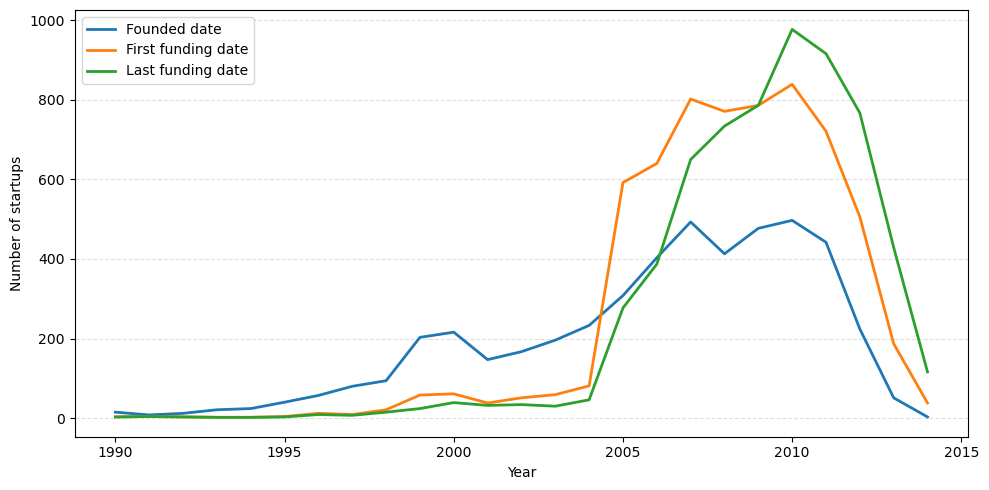

In [7]:
temporal_coverage = []

for col in date_cols:
    year_counts = (
        df_eda[col]
        .dropna()
        .dt.year
        .value_counts()
        .sort_index()
    )

    for year, count in year_counts.items():
        temporal_coverage.append({
            "year": int(year),
            "date_variable": col,
            "count": int(count)
        })

temporal_coverage = pd.DataFrame(temporal_coverage)

temporal_coverage_clean = temporal_coverage[
    temporal_coverage["year"] >= MIN_YEAR_CUTOFF
].copy()

temporal_coverage_clean["date_variable"] = temporal_coverage_clean["date_variable"].replace({
    "founded_at": "Founded date",
    "first_funding_at": "First funding date",
    "last_funding_at": "Last funding date"
})

temporal_coverage_figure = plt.figure(figsize=(10, 5))

sns.lineplot(
    data=temporal_coverage_clean,
    x="year",
    y="count",
    hue="date_variable",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Number of startups")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title=None)
plt.tight_layout()


plt.show()

## 6. Temporal cutoff diagnostics

This table supports the 1990 cutoff used during data cleaning. It compares imputed founding year and first funding year by decade and reports the retained sample percentage for each cutoff point.

In [8]:
def decade_cutoff_summary(
    df: pd.DataFrame,
    year_col: str,
    output_prefix: str
) -> pd.DataFrame:
    decade_bins = [-np.inf, 1960, 1970, 1980, 1990, 2000, 2010, 2020]
    decade_labels = [
        "Before 1960",
        "1960-1969",
        "1970-1979",
        "1980-1989",
        "1990-1999",
        "2000-2009",
        "2010-2019",
    ]

    temp = df.copy()
    temp[year_col] = pd.to_numeric(temp[year_col], errors="coerce")
    total_n = len(temp)

    temp["decade"] = pd.cut(
        temp[year_col],
        bins=decade_bins,
        labels=decade_labels,
        right=False
    )

    decade_counts = (
        temp
        .groupby("decade", observed=False)
        .size()
        .reset_index(name="count")
    )

    decade_counts["percentage"] = (
        decade_counts["count"] / total_n * 100
    ).round(2)

    cutoff_map = {
        "Before 1960": 100.00,
        "1960-1969": (temp[year_col] >= 1960).mean() * 100,
        "1970-1979": (temp[year_col] >= 1970).mean() * 100,
        "1980-1989": (temp[year_col] >= 1980).mean() * 100,
        "1990-1999": (temp[year_col] >= 1990).mean() * 100,
        "2000-2009": (temp[year_col] >= 2000).mean() * 100,
        "2010-2019": (temp[year_col] >= 2010).mean() * 100,
    }

    decade_counts["retained_percentage"] = (
        decade_counts["decade"]
        .astype(str)
        .map(cutoff_map)
        .round(2)
    )

    decade_counts = decade_counts.rename(columns={
        "decade": f"{output_prefix}_decade",
        "count": f"{output_prefix}_count",
        "percentage": f"{output_prefix}_percentage",
        "retained_percentage": f"{output_prefix}_retained_percentage"
    })

    return decade_counts


df_cutoff = df_eda.copy()

df_cutoff["founded_year_numeric"] = pd.to_numeric(
    df_cutoff["founded_year"],
    errors="coerce"
)

df_cutoff["first_funding_year"] = df_cutoff["first_funding_at"].dt.year

df_cutoff["founded_year_imputed"] = (
    df_cutoff["founded_year_numeric"]
    .fillna(df_cutoff["first_funding_year"])
)

founded_summary = decade_cutoff_summary(
    df_cutoff,
    "founded_year_imputed",
    "imputed_founding_year"
)

first_funding_summary = decade_cutoff_summary(
    df_cutoff,
    "first_funding_year",
    "first_funding_year"
)

temporal_cutoff_diagnostics = pd.concat(
    [founded_summary, first_funding_summary.drop(columns=["first_funding_year_decade"])],
    axis=1
)


display(temporal_cutoff_diagnostics)

,imputed_founding_year_decade,imputed_founding_year_count,imputed_founding_year_percentage,imputed_founding_year_retained_percentage,first_funding_year_count,first_funding_year_percentage,first_funding_year_retained_percentage
0,Before 1960,6,0.10,100.00,1,0.02,100.00
1,1960-1969,9,0.14,99.90,2,0.03,99.98
2,1970-1979,21,0.33,99.76,0,0.00,99.95
3,1980-1989,108,1.72,99.43,2,0.03,99.95
4,1990-1999,566,8.99,97.71,118,1.87,99.92
5,2000-2009,3933,62.48,88.72,3881,61.65,98.05
6,2010-2019,1652,26.24,26.24,2291,36.39,36.39


## 7. Time-order and duplicate checks

These checks document chronological inconsistencies and exact duplicate rows in the binary analytic sample.

In [9]:
temporal_checks = []

if {"founded_at", "first_funding_at"}.issubset(df_eda.columns):
    mask_founded_after_first = (
        df_eda["founded_at"].notna()
        & df_eda["first_funding_at"].notna()
        & (df_eda["founded_at"] > df_eda["first_funding_at"])
    )

    temporal_checks.append({
        "check": "founded_at_after_first_funding_at",
        "flagged_rows": int(mask_founded_after_first.sum())
    })

if {"first_funding_at", "last_funding_at"}.issubset(df_eda.columns):
    mask_first_after_last = (
        df_eda["first_funding_at"].notna()
        & df_eda["last_funding_at"].notna()
        & (df_eda["first_funding_at"] > df_eda["last_funding_at"])
    )

    temporal_checks.append({
        "check": "first_funding_at_after_last_funding_at",
        "flagged_rows": int(mask_first_after_last.sum())
    })

duplicate_count = int(df_eda.duplicated().sum())

temporal_checks.append({
    "check": "exact_duplicate_rows",
    "flagged_rows": duplicate_count
})

temporal_checks_table = pd.DataFrame(temporal_checks)

display(temporal_checks_table)


,check,flagged_rows
0,founded_at_after_first_funding_at,447
1,first_funding_at_after_last_funding_at,0
2,exact_duplicate_rows,0


## 8. Funding-variable skewness

This table reports skewness for funding-related numeric variables in the binary analytic sample. It supports the use of `log1p` transformation in preprocessing.

In [10]:
funding_cols = [
    "funding_total_usd",
    "seed",
    "venture",
    "angel",
    "grant",
    "debt_financing",
    "private_equity",
    "equity_crowdfunding",
    "convertible_note",
    "undisclosed",
    "product_crowdfunding",
    "round_a",
    "round_b",
    "round_c",
    "round_d",
    "round_e",
    "round_f",
    "round_g",
    "round_h",
]

funding_cols = [col for col in funding_cols if col in df_eda.columns]

for col in funding_cols:
    df_eda[col] = pd.to_numeric(
        df_eda[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

funding_skewness = []

for col in funding_cols:
    funding_skewness.append({
        "variable": col,
        "skewness": round(df_eda[col].dropna().skew(), 2)
    })

funding_skewness = pd.DataFrame(funding_skewness)

display(funding_skewness)


,variable,skewness
0,funding_total_usd,44.45
1,seed,16.52
2,venture,10.86
3,angel,31.83
4,grant,57.67
5,debt_financing,34.82
6,private_equity,19.51
7,equity_crowdfunding,64.11
8,convertible_note,51.07
9,undisclosed,41.81


## 9. Geographic and market distributions

These tables report the top categories for `country_code` and `market` in the binary analytic sample.

In [11]:
categorical_distribution_tables = {}

for col in ["country_code", "market"]:
    if col not in df_eda.columns:
        continue

    dist = (
        df_eda[col]
        .fillna("missing")
        .value_counts()
        .rename_axis(col)
        .reset_index(name="count")
    )

    dist["percentage"] = (dist["count"] / len(df_eda) * 100).round(2)

    categorical_distribution_tables[col] = dist

    print(f"Top 10 categories for {col}")
    display(dist.head(10))


Top 10 categories for country_code


,country_code,count,percentage
0,USA,4248,67.48
1,missing,628,9.98
2,GBR,297,4.72
3,CAN,169,2.68
4,DEU,118,1.87
5,ISR,107,1.70
6,FRA,94,1.49
7,CHN,61,0.97
8,ESP,58,0.92
9,IND,50,0.79


Top 10 categories for market


,market,count,percentage
0,Software,718,11.41
1,Curated Web,459,7.29
2,Mobile,342,5.43
3,Biotechnology,322,5.12
4,Enterprise Software,249,3.96
5,missing,231,3.67
6,Games,227,3.61
7,Advertising,214,3.40
8,E-Commerce,188,2.99
9,Social Media,162,2.57


In [12]:
if {"country_code", "market"}.issubset(categorical_distribution_tables):
    top_country = categorical_distribution_tables["country_code"].head(10).copy()
    top_country = top_country.rename(columns={
        "country_code": "category",
        "count": "country_count",
        "percentage": "country_percentage"
    })

    top_market = categorical_distribution_tables["market"].head(10).copy()
    top_market = top_market.rename(columns={
        "market": "category",
        "count": "market_count",
        "percentage": "market_percentage"
    })

    top_country_market = pd.concat(
        [
            top_country[["category", "country_count", "country_percentage"]],
            top_market[["category", "market_count", "market_percentage"]]
        ],
        axis=1
    )

    display(top_country_market)


,category,country_count,country_percentage,category,market_count,market_percentage
0,USA,4248,67.48,Software,718,11.41
1,missing,628,9.98,Curated Web,459,7.29
2,GBR,297,4.72,Mobile,342,5.43
3,CAN,169,2.68,Biotechnology,322,5.12
4,DEU,118,1.87,Enterprise Software,249,3.96
5,ISR,107,1.70,missing,231,3.67
6,FRA,94,1.49,Games,227,3.61
7,CHN,61,0.97,Advertising,214,3.40
8,ESP,58,0.92,E-Commerce,188,2.99
9,IND,50,0.79,Social Media,162,2.57


## 10. Save outputs

This section saves the EDA summary tables and temporal coverage figure for later reporting.


In [13]:
# Save summary tables generated above.
status_counts.to_csv(EDA_TABLE_DIR / "raw_status_distribution.csv", index=False)
binary_status_counts.to_csv(EDA_TABLE_DIR / "binary_sample_status_distribution.csv", index=False)
missing_table.to_csv(EDA_TABLE_DIR / "missing_data_binary_sample.csv", index=False)
temporal_summary.to_csv(EDA_TABLE_DIR / "temporal_coverage_summary.csv", index=False)
temporal_cutoff_diagnostics.to_csv(EDA_TABLE_DIR / "temporal_cutoff_diagnostics.csv", index=False)
temporal_checks_table.to_csv(EDA_TABLE_DIR / "time_order_and_duplicate_checks.csv", index=False)
funding_skewness.to_csv(EDA_TABLE_DIR / "funding_variable_skewness.csv", index=False)

for col, dist in categorical_distribution_tables.items():
    dist.to_csv(EDA_TABLE_DIR / f"{col}_distribution.csv", index=False)

top_country_market.to_csv(
    EDA_TABLE_DIR / "top_10_country_and_market_categories.csv",
    index=False
)

# Save figure generated above.
temporal_coverage_figure.savefig(
    EDA_FIGURE_DIR / "temporal_coverage_date_variables.png",
    dpi=300,
    bbox_inches="tight"
)
